# 📓 Notebook: Exploratory Data Analysis – Extreme Weather Events

### 📌 Objective

This notebook performs exploratory data analysis (EDA) on the finalized
Extreme Events dataset.

The dataset contains daily extreme weather events identified using
station-specific 95th percentile (P95) thresholds and includes:
- Extreme Wind
- Heavy Precipitation

The focus of this analysis is event frequency, distribution, and
temporal variability.

### 1️⃣ Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### 2️⃣ Load the finalized dataset

The Extreme Events dataset used here is the final, standardized version
generated from the Extreme Events creation notebook.

All event magnitudes are stored in a single `EventValue` field.

In [2]:
# Load extreme events dataset
extreme = pd.read_csv(
    "../Capstone/clean data/Fact_Extreme_Events_All.csv",
    parse_dates=["Date/Time"]
)

# Basic structure
extreme.head()
extreme.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60378 entries, 0 to 60377
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   ClimateID      60378 non-null  object        
 1   Date/Time      60378 non-null  datetime64[ns]
 2   EventType      60378 non-null  object        
 3   EventValue     60378 non-null  float64       
 4   P95_Threshold  60378 non-null  float64       
 5   ExtremeFlag    60378 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 2.8+ MB


### 3️⃣ Data quality check

Before proceeding with exploratory analysis, we validate the dataset
for missing values and structural consistency.

In [3]:
extreme.isna().sum()

ClimateID        0
Date/Time        0
EventType        0
EventValue       0
P95_Threshold    0
ExtremeFlag      0
dtype: int64

### 4️⃣ Summary statistics

Summary statistics provide an initial overview of event magnitudes
relative to their station-specific thresholds.

In [4]:
extreme[["EventValue", "P95_Threshold"]].describe()

,EventValue,P95_Threshold
count,60378.000000,60378.000000
mean,52.988309,42.397042
std,32.414863,30.793159
min,0.000000,0.000000
25%,23.800000,16.700000
50%,40.900000,22.200000
75%,80.000000,72.000000
max,259.700000,117.000000


In [5]:
#Extreme Wind and Heavy Precipitation represent different physical processes and are summarized separately.

extreme.groupby("EventType")["EventValue"].describe()

,count,mean,std,min,25%,50%,75%,max
EventType,,,,,,,,
Extreme Wind,25045.0,86.560910,17.395739,50.0,74.0,84.0,96.0,185.0
Heavy Precipitation,35333.0,29.191127,14.688470,0.0,20.0,25.5,33.9,259.7


### 5️⃣ Event frequency analysis

In [6]:
#Event counts by type
extreme["EventType"].value_counts()

EventType
Heavy Precipitation    35333
Extreme Wind           25045
Name: count, dtype: int64

Heavy precipitation extreme events occur more frequently than extreme
wind events across the historical record.

#### Events per station

Examining the number of extreme events per station highlights spatial
heterogeneity in extreme weather exposure.

In [7]:
events_per_station = extreme.groupby("ClimateID").size()
events_per_station.describe()

count    136.000000
mean     443.955882
std      236.764389
min        1.000000
25%      257.500000
50%      457.000000
75%      627.250000
max      961.000000
dtype: float64

### 6️⃣ Temporal analysis
Event frequency per year

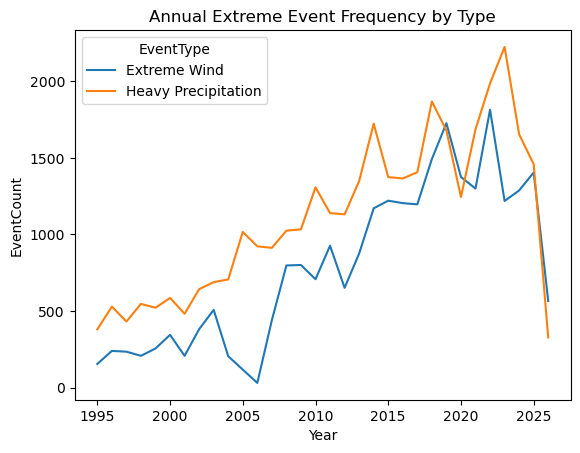

In [8]:
extreme["Year"] = extreme["Date/Time"].dt.year

events_per_year = (
    extreme
    .groupby(["Year", "EventType"])
    .size()
    .reset_index(name="EventCount")
)

sns.lineplot(
    data=events_per_year,
    x="Year",
    y="EventCount",
    hue="EventType"
)
plt.title("Annual Extreme Event Frequency by Type")
plt.show()

### 7️⃣ Distribution of event magnitudes

EventValue distributions are evaluated separately by event type due to
differences in physical units (km/h vs mm).

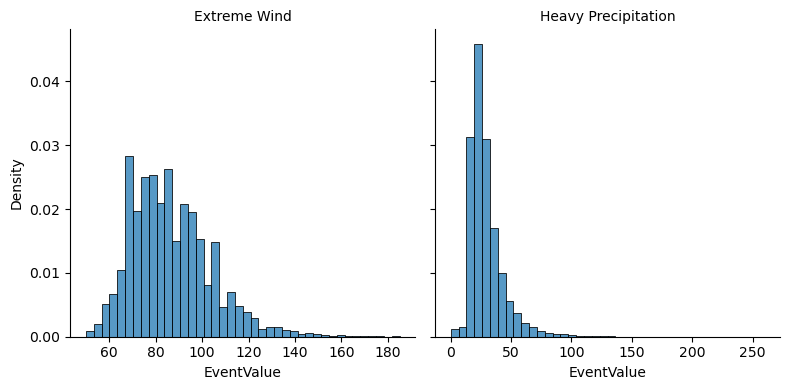

In [9]:
g = sns.FacetGrid(
    extreme,
    col="EventType",
    sharex=False,
    height=4
)

g.map_dataframe(
    sns.histplot,
    x="EventValue",
    bins=40,
    stat="density"
)

g.set_titles("{col_name}")
plt.show()

### 8️⃣ Threshold validation

A strong relationship between event magnitudes and station-specific
P95 thresholds confirms internal consistency of the extreme event
definition.

In [10]:
extreme[["EventValue", "P95_Threshold"]].corr()

,EventValue,P95_Threshold
EventValue,1.000000,0.927271
P95_Threshold,0.927271,1.000000


## 9️⃣ Key Exploratory Findings

- Extreme wind and heavy precipitation events exhibit clear interannual
  variability, with higher event frequency observed in more recent
  decades at Nova Scotia stations.

- Event frequency varies significantly across stations, indicating
  Extreme events are not evenly spread across the study area.

- Station-specific percentile thresholds (P95) provide a robust,
  location-aware definition of extreme events compared to fixed
  thresholds.

- Heavy precipitation events occur more frequently than extreme wind
  events, consistent with regional climatic behavior.

- The dataset is complete and validated, with no missing values
  affecting downstream analysis.

### ✅ Final Notes

This notebook is intended for exploratory analysis only.
No data correction or transformation is performed here.

All structural adjustments are handled upstream in the Extreme Events
generation pipeline.